In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
scratch = "/pscratch/sd/n/nagarwal/"
expt = "ocn-only"
run = "R5"
corr_file = "input_correlation_singvalues.npz"

In [4]:
corr_data = np.load(os.path.join(scratch, expt, run, corr_file))

## Correlation Matrix

In [5]:
corr = corr_data["correlation_matrix"]

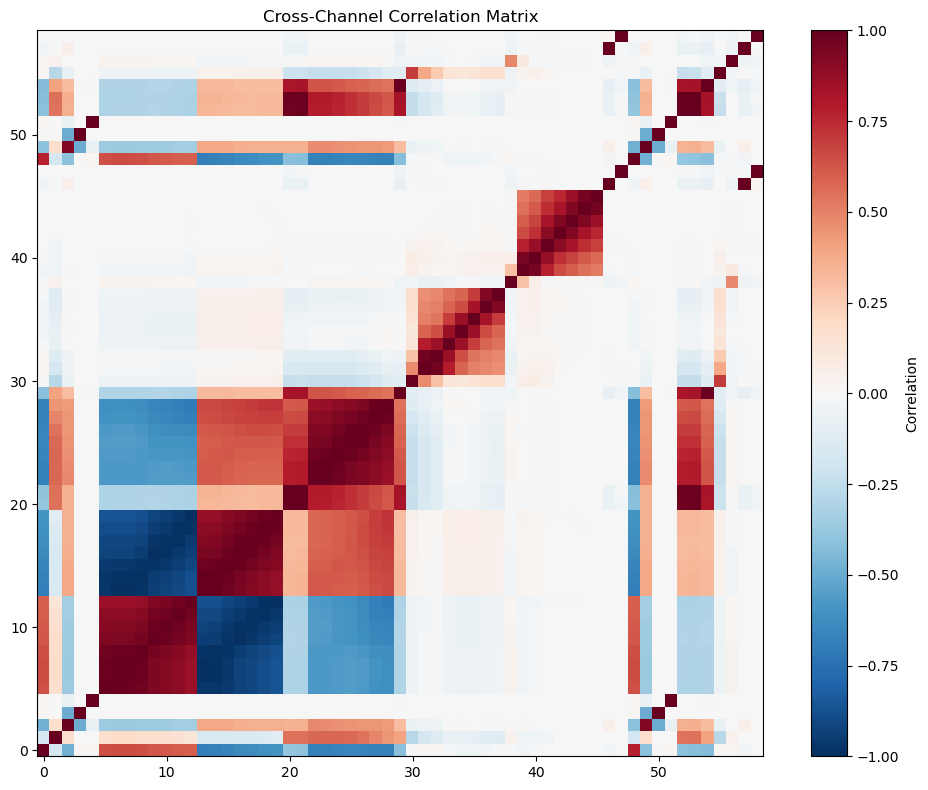

In [6]:
plt.figure(figsize=(10, 8))
f = plt.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
f.axes.invert_yaxis()
plt.colorbar(label='Correlation')
plt.title('Cross-Channel Correlation Matrix')
plt.tight_layout()
plt.show()

## Eigen Values

In [11]:
eigvals = corr_data['eigenvalues']
eigvals

array([ 2.09738205e+01,  7.10666285e+00,  5.55421952e+00,  4.71425715e+00,
        2.75363739e+00,  2.08167217e+00,  2.00315170e+00,  2.00055742e+00,
        1.71500168e+00,  1.52095951e+00,  1.32102188e+00,  1.05220098e+00,
        8.93218062e-01,  8.50233431e-01,  5.99027617e-01,  5.36428146e-01,
        5.11135415e-01,  4.86403270e-01,  3.13096210e-01,  2.94342140e-01,
        2.80786238e-01,  2.43619829e-01,  1.82128679e-01,  1.58643241e-01,
        1.45824371e-01,  1.12395651e-01,  9.02804886e-02,  5.91097985e-02,
        5.74745224e-02,  4.88191148e-02,  4.75338462e-02,  4.27034550e-02,
        3.25188880e-02,  3.14921013e-02,  2.78482032e-02,  2.71024432e-02,
        1.98056727e-02,  1.64924555e-02,  1.60357608e-02,  1.39842052e-02,
        9.29796457e-03,  8.36802903e-03,  7.77524670e-03,  7.72233262e-03,
        5.68188338e-03,  5.06499494e-03,  3.74274597e-03,  3.43885930e-03,
        3.05013802e-03,  2.48148447e-03,  1.96544163e-03,  1.01877177e-03,
        9.59800412e-04,  

/tmp/ipykernel_727788/3209578662.py:1: RuntimeWarning: invalid value encountered in sqrt
  plt.plot(np.arange(1, len(eigvals)+1, 1), np.sqrt(eigvals))


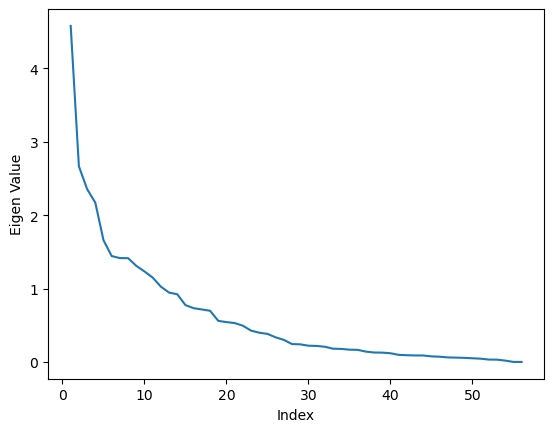

In [12]:
plt.plot(np.arange(1, len(eigvals)+1, 1), np.sqrt(eigvals))
plt.ylabel("Eigen Value")
plt.xlabel('Index')
plt.show()

## Singular Values

In [13]:
singvals = corr_data['singular_values']
singvals

array([2.42347307e+05, 1.41069225e+05, 1.24712775e+05, 1.14896304e+05,
       8.78117837e+04, 7.63493937e+04, 7.48956069e+04, 7.48470925e+04,
       6.92997550e+04, 6.52616801e+04, 6.08211223e+04, 5.42811168e+04,
       5.00124548e+04, 4.87942349e+04, 4.09565010e+04, 3.87574506e+04,
       3.78327064e+04, 3.69060586e+04, 2.96099947e+04, 2.87095011e+04,
       2.80406020e+04, 2.61189516e+04, 2.25833618e+04, 2.10770687e+04,
       2.02075880e+04, 1.77408399e+04, 1.58999725e+04, 1.28655739e+04,
       1.26863623e+04, 1.16921499e+04, 1.15372128e+04, 1.09353058e+04,
       9.54261203e+03, 9.39074924e+03, 8.83075861e+03, 8.71171473e+03,
       7.44722068e+03, 6.79582339e+03, 6.70107083e+03, 6.25775156e+03,
       5.10262165e+03, 4.84073171e+03, 4.66612655e+03, 4.65022189e+03,
       3.98883050e+03, 3.76607472e+03, 3.23738686e+03, 3.10317757e+03,
       2.92253129e+03, 2.63605948e+03, 2.34600805e+03, 1.68903199e+03,
       1.63941872e+03, 9.49191171e+02, 9.60898264e-04, 7.47382233e-04,
      

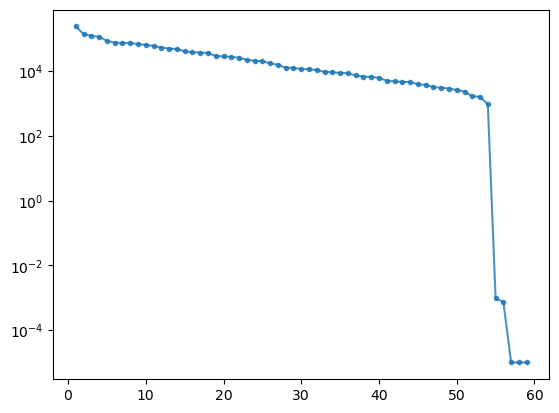

In [19]:
fig, ax = plt.subplots(1, 1)
# Impute nans with a small value so that it shows up on the spectrum,
# otherwise it misrepresents num of zero sing values
singvals_imputed = np.nan_to_num(singvals, nan=1e-5)
sorted_singvals = sorted(singvals_imputed, reverse=True)
indices = np.arange(1, len(sorted_singvals) + 1)

ax.plot(indices, sorted_singvals, marker='.', linestyle='-', alpha=0.8)
ax.set_yscale('log')